In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv1D,MaxPooling1D,LSTM,Dense,Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

In [52]:
def clean_stock_data(file_path):
    # Load dataset
    df = pd.read_csv(file_path)

    print("Original shape:", df.shape)

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort from oldest to newest
    df = df.sort_values("Date").reset_index(drop=True)

    # Check and remove duplicate rows
    duplicate_rows = df.duplicated().sum()
    print("Duplicate rows:", duplicate_rows)

    df = df.drop_duplicates()

    # Check and remove duplicate dates
    duplicate_dates = df.duplicated(subset=["Date"]).sum()
    print("Duplicate dates:", duplicate_dates)

    df = df.drop_duplicates(subset=["Date"], keep="first")

    # Check missing values
    print("\nMissing values before handling:")
    print(df.isnull().sum())

    # Handle missing values
    price_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close"
    ]

    df[price_columns] = df[price_columns].ffill()
    df[price_columns] = df[price_columns].bfill()

    # Remove observations with missing Volume
    df = df.dropna(subset=["Volume"])

    # Final validation
    df = df.sort_values("Date").reset_index(drop=True)

    print("\nMissing values after handling:")
    print(df.isnull().sum())

    print("\nFinal shape:", df.shape)

    return df

In [53]:
print("===== AAPL =====")
aapl = clean_stock_data("Dataset/AAPL_historical_data.csv")

print("\n===== NVDA =====")
nvda = clean_stock_data("Dataset/NVDA_historical_data.csv")

print("\n===== JPM =====")
jpm = clean_stock_data("Dataset/JPM_historical_data.csv")

print("\n===== BHP =====")
bhp = clean_stock_data("Dataset/BHP.AX_historical_data.csv")

print("\n===== CBA =====")
cba = clean_stock_data("Dataset/CBA.AX_historical_data.csv")

print("\n===== GMG =====")
gmg = clean_stock_data("Dataset/GMG.AX_historical_data.csv")

===== AAPL =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== NVDA =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== JPM =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
A

In [54]:
print(aapl.head())
print(aapl.tail())

        Date   Open   High    Low  Close  Adj Close     Volume
0 2018-01-02  42.54  43.08  42.31  43.06      40.23  102223600
1 2018-01-03  43.13  43.64  42.99  43.06      40.23  118071600
2 2018-01-04  43.13  43.37  43.02  43.26      40.41   89738400
3 2018-01-05  43.36  43.84  43.26  43.75      40.87   94640000
4 2018-01-08  43.59  43.90  43.48  43.59      40.72   82271200
           Date    Open    High     Low   Close  Adj Close    Volume
2005 2025-12-23  270.84  272.50  269.56  272.36     271.62  29642000
2006 2025-12-24  272.34  275.43  272.20  273.81     273.07  17910600
2007 2025-12-26  274.16  275.37  272.86  273.40     272.66  21521800
2008 2025-12-29  272.69  274.36  272.35  273.76     273.02  23715200
2009 2025-12-30  272.81  274.08  272.28  273.08     272.34  22139600


In [55]:
print(nvda.head())
print(nvda.tail())

        Date  Open  High   Low  Close  Adj Close     Volume
0 2018-01-02  4.89  4.99  4.86   4.98       4.92  355616000
1 2018-01-03  5.10  5.34  5.09   5.31       5.25  914704000
2 2018-01-04  5.39  5.45  5.32   5.34       5.27  583268000
3 2018-01-05  5.35  5.42  5.28   5.39       5.32  580124000
4 2018-01-08  5.51  5.62  5.46   5.55       5.48  881216000
           Date    Open    High     Low   Close  Adj Close     Volume
2005 2025-12-23  182.97  189.33  182.90  189.21     188.98  174873600
2006 2025-12-24  187.94  188.91  186.59  188.61     188.38   65528500
2007 2025-12-26  189.92  192.69  188.00  190.53     190.30  139740300
2008 2025-12-29  187.71  188.76  185.91  188.22     187.99  120006100
2009 2025-12-30  188.24  188.99  186.93  187.54     187.31   97687300


In [56]:
print(jpm.head())
print(jpm.tail())

        Date    Open    High     Low   Close  Adj Close    Volume
0 2018-01-02  107.63  108.02  106.81  107.95      85.52  13578800
1 2018-01-03  107.86  108.49  107.48  108.06      85.60  11901000
2 2018-01-04  108.36  110.03  108.20  109.04      86.83  12953700
3 2018-01-05  109.26  109.55  107.78  108.34      86.27  14155000
4 2018-01-08  108.15  108.68  107.70  108.50      86.40  12466500
           Date    Open    High     Low   Close  Adj Close   Volume
2005 2025-12-23  323.61  327.78  323.09  325.93     321.37  6668300
2006 2025-12-24  326.24  329.99  325.50  329.17     324.56  4289300
2007 2025-12-26  329.11  330.86  326.54  327.91     323.32  4158300
2008 2025-12-29  327.00  327.77  323.53  323.75     319.22  8635300
2009 2025-12-30  324.81  324.94  322.49  323.42     318.89  7904300


In [57]:
print(bhp.head())
print(bhp.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  26.27  26.49  26.27  26.43      14.42  3653331
1 2018-01-03  26.93  27.02  26.86  26.87      14.66  7624353
2 2018-01-04  27.09  27.25  26.98  27.01      14.74  6178215
3 2018-01-05  27.29  27.33  27.17  27.23      14.86  6553946
4 2018-01-08  27.20  27.30  27.10  27.20      14.84  3677542
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  44.85  45.17  44.72  45.07      44.23  5527196
2020 2025-12-23  45.60  45.71  45.30  45.58      44.73  4534942
2021 2025-12-24  45.78  45.78  45.50  45.62      44.77  2112731
2022 2025-12-29  45.90  46.03  45.45  45.45      44.60  4680346
2023 2025-12-30  44.80  45.39  44.70  45.10      44.26  4171339


In [58]:
print(cba.head())
print(cba.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  80.30  80.33  79.78  80.22      55.57  1284609
1 2018-01-03  80.47  80.64  80.06  80.14      55.51  1349269
2 2018-01-04  80.48  80.48  79.81  79.97      55.40  1596303
3 2018-01-05  80.54  81.25  80.37  81.16      56.22  2208531
4 2018-01-08  81.40  81.75  81.30  81.62      56.54  1293549
           Date    Open    High     Low   Close  Adj Close   Volume
2019 2025-12-22  158.00  159.68  157.24  158.26     153.58  1396340
2020 2025-12-23  158.55  161.80  158.55  161.73     156.95  1520620
2021 2025-12-24  161.33  161.50  160.33  161.39     156.62   653329
2022 2025-12-29  161.31  162.24  160.49  160.49     155.74  1091076
2023 2025-12-30  162.25  163.10  161.09  161.29     156.52   995378


In [59]:
print(gmg.head())
print(gmg.tail())

        Date  Open  High   Low  Close  Adj Close   Volume
0 2018-01-02  8.40  8.48  8.34   8.44       7.40  1519605
1 2018-01-03  8.44  8.47  8.36   8.43       7.39  1625146
2 2018-01-04  8.47  8.49  8.39   8.47       7.42  2691250
3 2018-01-05  8.48  8.49  8.35   8.39       7.35  3161786
4 2018-01-08  8.40  8.45  8.37   8.39       7.35  2335220
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  29.09  29.31  28.88  29.22      28.94  2211236
2020 2025-12-23  30.91  31.92  30.68  31.63      31.33  5097836
2021 2025-12-24  31.51  31.67  31.20  31.65      31.35  2150732
2022 2025-12-29  31.54  31.57  30.98  31.32      31.02  2941775
2023 2025-12-30  31.64  31.87  30.77  30.95      30.80  2934635


In [60]:
# Storing all cleaned stock datasets in one dictionary
stocks = {
    "AAPL": aapl,
    "NVDA": nvda,
    "JPM": jpm,
    "BHP": bhp,
    "CBA": cba,
    "GMG": gmg
}

In [61]:
# Storing the summary
summary = []

for stock_name, df in stocks.items():
    
    summary.append({
        "Stock": stock_name,
        "Rows": len(df),
        "Start Date": df["Date"].min(),
        "End Date": df["Date"].max(),
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

# Converting result into a dataframe
summary_df = pd.DataFrame(summary)

summary_df

,Stock,Rows,Start Date,End Date,Missing Values,Duplicate Rows
0,AAPL,2010,2018-01-02,2025-12-30,0,0
1,NVDA,2010,2018-01-02,2025-12-30,0,0
2,JPM,2010,2018-01-02,2025-12-30,0,0
3,BHP,2024,2018-01-02,2025-12-30,0,0
4,CBA,2024,2018-01-02,2025-12-30,0,0
5,GMG,2024,2018-01-02,2025-12-30,0,0


In [62]:
# Summary statistics for each stock
for stock_name, df in stocks.items():
    
    print("\n", stock_name)
    
    print(df[
        ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    ].describe())


 AAPL
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2010.000000  2010.000000   
mean    137.498756   139.022338   136.103622   137.632085   135.080836   
std      66.203729    66.845908    65.621446    66.269856    66.581243   
min      35.990000    36.430000    35.500000    35.550000    33.710000   
25%      66.500000    67.170000    65.777500    66.625000    64.207500   
50%     145.510000   147.230000   144.105000   145.860000   142.545000   
75%     184.395000   186.490000   182.642500   184.742500   182.357500   
max     286.200000   288.620000   283.300000   286.190000   285.410000   

             Volume  
count  2.010000e+03  
mean   9.446075e+07  
std    5.446452e+07  
min    1.791060e+07  
25%    5.564338e+07  
50%    8.098160e+07  
75%    1.151486e+08  
max    4.265100e+08  

 NVDA
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2

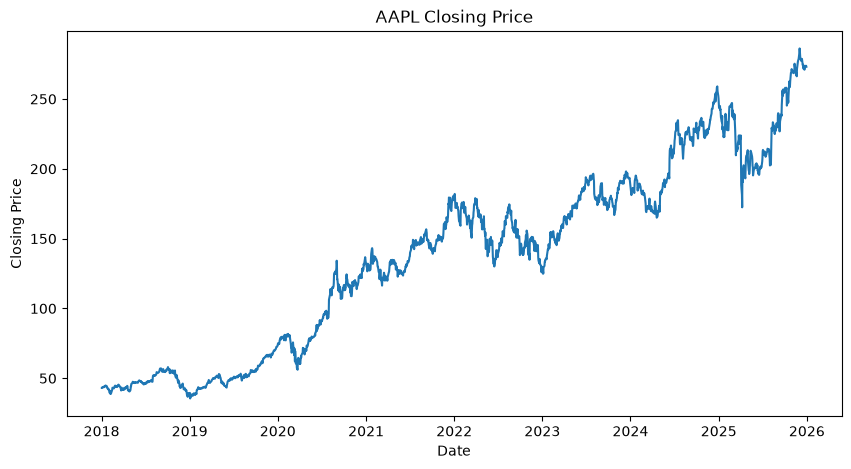

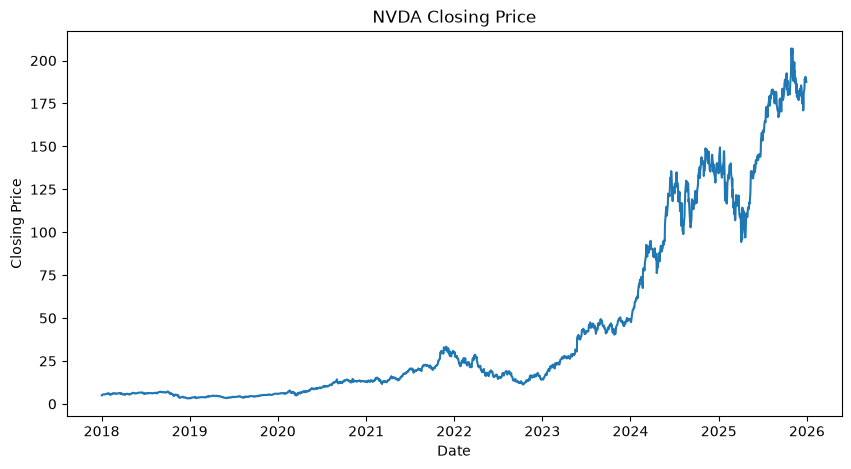

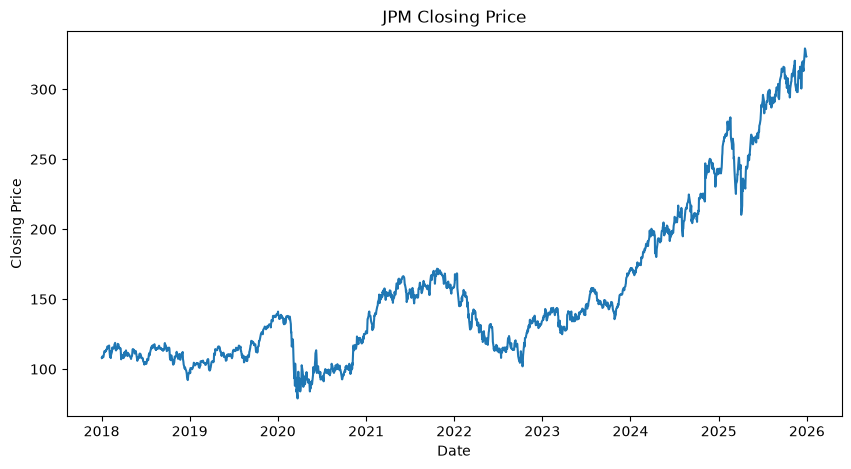

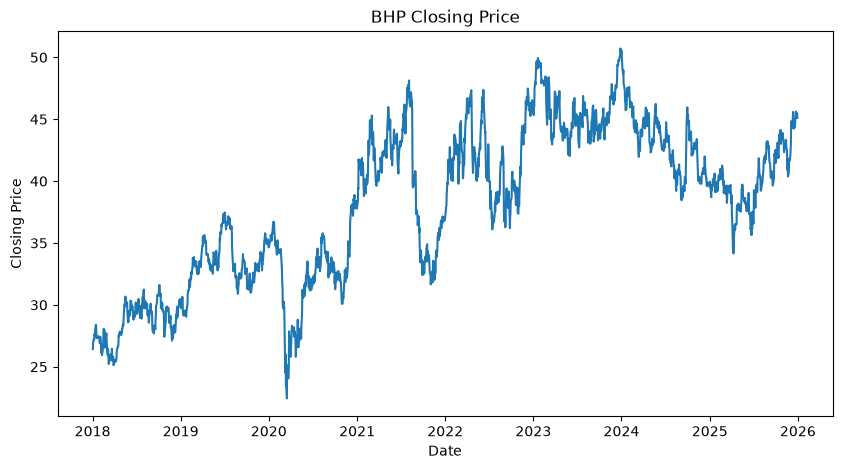

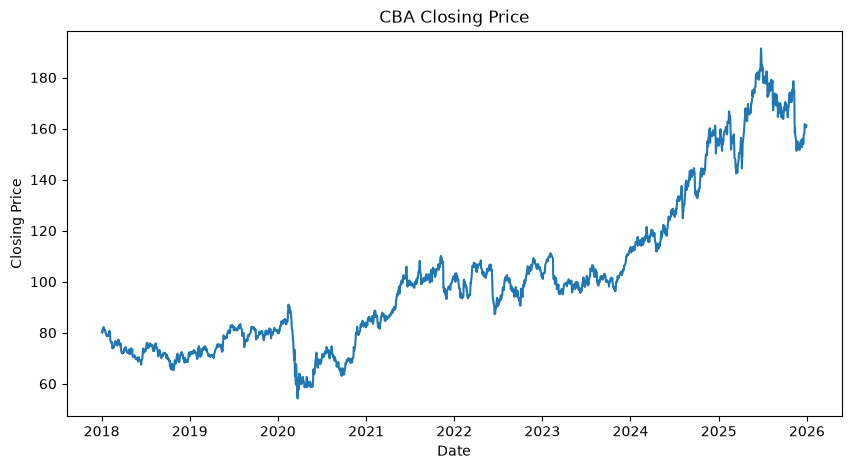

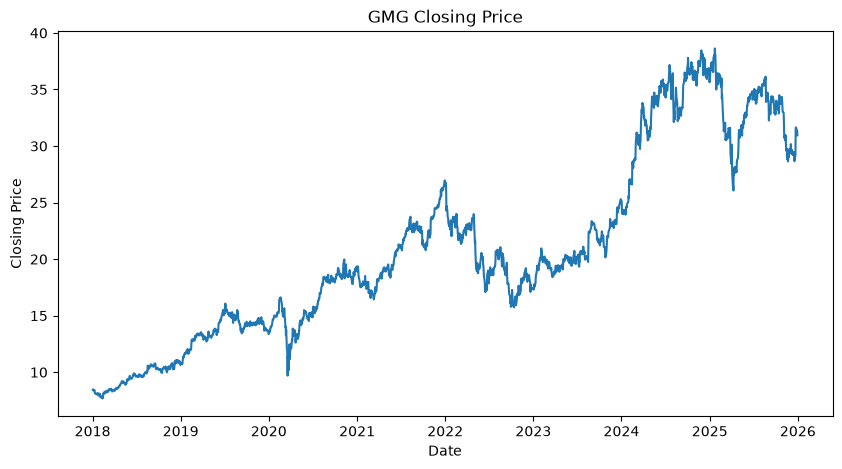

In [63]:
# Plotting the closing price over time
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(df["Date"], df["Close"])
    
    plt.title(stock_name + " Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    
    plt.show()

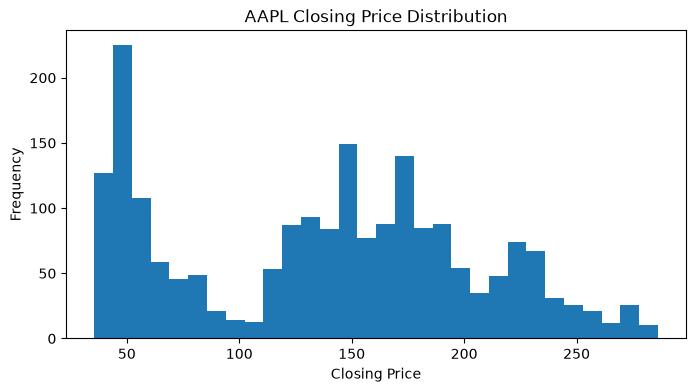

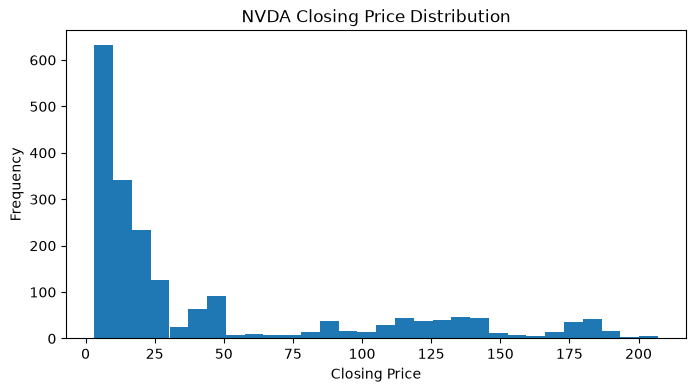

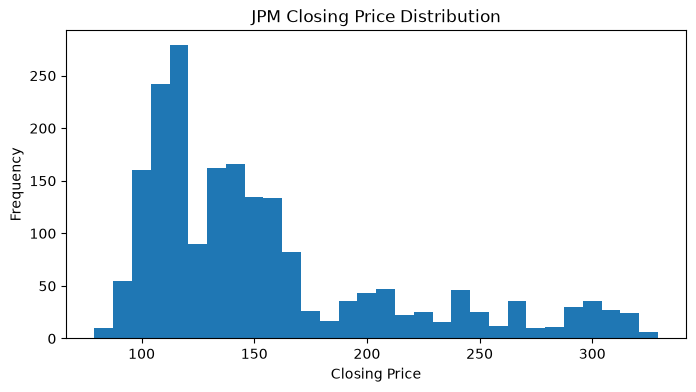

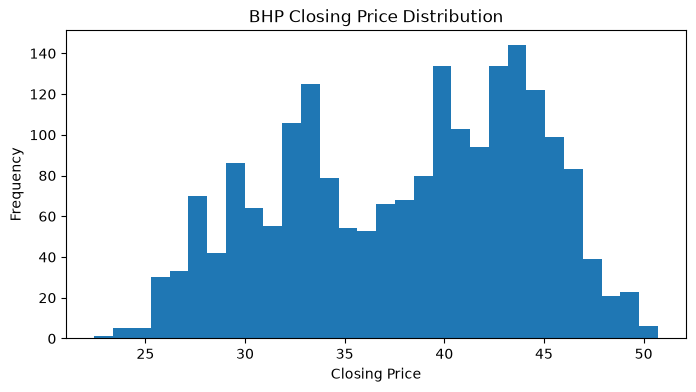

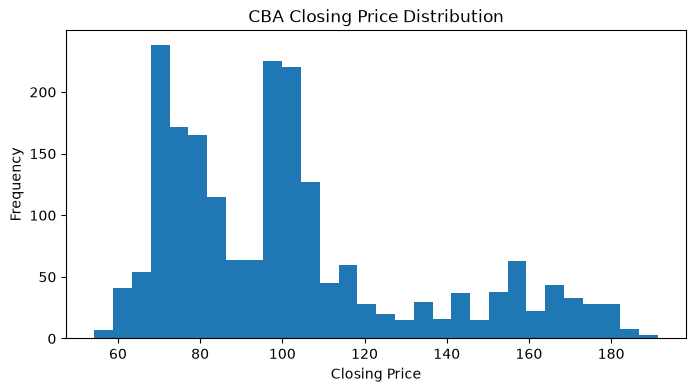

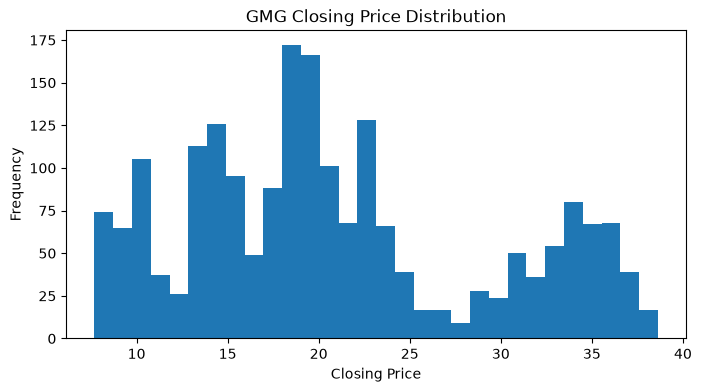

In [64]:
# Distribution of closing prices
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(df["Close"], bins=30)
    
    plt.title(stock_name + " Closing Price Distribution")
    plt.xlabel("Closing Price")
    plt.ylabel("Frequency")
    
    plt.show()

In [65]:
# Checking IQR outliers in closing prices
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    print(stock_name)
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print()

AAPL
Lower limit: -110.55
Upper limit: 361.92
Number of outliers: 0

NVDA
Lower limit: -57.95
Upper limit: 114.0
Number of outliers: 347

JPM
Lower limit: 27.94
Upper limit: 255.69
Number of outliers: 191

BHP
Lower limit: 17.13
Upper limit: 59.12
Number of outliers: 0

CBA
Lower limit: 24.41
Upper limit: 164.26
Number of outliers: 143

GMG
Lower limit: -1.43
Upper limit: 41.22
Number of outliers: 0



In [66]:
# Checking date range of IQR outliers
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    if len(outliers) > 0:
        print(stock_name)
        print("Number of outliers:", len(outliers))
        print("First outlier:", outliers["Date"].min())
        print("Last outlier:", outliers["Date"].max())
        print()

NVDA
Number of outliers: 347
First outlier: 2024-05-29 00:00:00
Last outlier: 2025-12-30 00:00:00

JPM
Number of outliers: 191
First outlier: 2025-01-17 00:00:00
Last outlier: 2025-12-30 00:00:00

CBA
Number of outliers: 143
First outlier: 2025-02-12 00:00:00
Last outlier: 2025-11-10 00:00:00



In [67]:
# Add technical indicators and lagged features to the stock dataset for analysis and modelling
def add_features(df):
    df = df.copy()

    # Daily percentage return
    df["Return"] = df["Close"].pct_change()

    # Simple Moving Averages
    df["SMA_10"] = df["Close"].rolling(window=10).mean()
    df["SMA_20"] = df["Close"].rolling(window=20).mean()

    # Exponential Moving Average
    df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

    # Rolling volatility
    df["Volatility_10"] = df["Return"].rolling(window=10).std()

    # Previous-day close
    df["Close_Lag_1"] = df["Close"].shift(1)

    # Previous-day return
    df["Return_Lag_1"] = df["Return"].shift(1)

    # RSI - Relative Strength Index
    rsi_period = 14

    delta = df["Close"].diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=rsi_period).mean()
    avg_loss = loss.rolling(window=rsi_period).mean()

    rs = avg_gain / avg_loss

    df["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD - Moving Average Convergence Divergence
    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema_12 - ema_26

    # MACD signal line
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # MACD histogram
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    return df

In [68]:
for stock_name in stocks:
    stocks[stock_name] = add_features(stocks[stock_name])

In [69]:
# Remove NaN values generated by feature engineering
for stock_name in stocks:
    stocks[stock_name] = stocks[stock_name].dropna().reset_index(drop=True)

print("NaN values removed successfully.")

NaN values removed successfully.


In [70]:
# Verify missing values after feature engineering
for stock_name, df in stocks.items():
    print(f"\n{stock_name}")
    print("Rows:", len(df))
    print("Missing values:", df.isnull().sum().sum())


AAPL
Rows: 1991
Missing values: 0

NVDA
Rows: 1991
Missing values: 0

JPM
Rows: 1991
Missing values: 0

BHP
Rows: 2005
Missing values: 0

CBA
Rows: 2005
Missing values: 0

GMG
Rows: 2005
Missing values: 0


In [71]:
# Remove rows with missing values from each stock dataset and reset the index
for stock_name in stocks:
    stocks[stock_name] = stocks[stock_name].dropna().reset_index(drop=True)

In [72]:
print(stocks["AAPL"].columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return',
       'SMA_10', 'SMA_20', 'EMA_10', 'Volatility_10', 'Close_Lag_1',
       'Return_Lag_1', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist'],
      dtype='str')


In [73]:
stocks["AAPL"].head(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Return,SMA_10,SMA_20,EMA_10,Volatility_10,Close_Lag_1,Return_Lag_1,RSI_14,MACD,MACD_Signal,MACD_Hist
0,2018-01-30,41.38,41.84,41.17,41.74,39.00,184192800,-0.005954,43.567,43.5840,43.065932,0.011164,41.99,-0.020756,31.526104,-0.189451,0.100055,-0.289507
1,2018-01-31,41.72,42.11,41.62,41.86,39.10,129915600,0.002875,43.275,43.5240,42.846671,0.008762,41.74,-0.005954,33.202358,-0.279841,0.024076,-0.303917
2,2018-02-01,41.79,42.15,41.69,41.94,39.19,188923200,0.001911,42.988,43.4680,42.681822,0.008886,41.86,0.002875,30.894309,-0.341088,-0.048957,-0.292132
3,2018-02-02,41.50,41.70,40.03,40.12,37.49,346375200,-0.043395,42.538,43.3110,42.216036,0.014563,41.94,0.001911,17.011129,-0.530372,-0.145240,-0.385132
4,2018-02-05,39.78,40.97,39.00,39.12,36.55,290954000,-0.024925,42.025,43.0795,41.653120,0.015221,40.12,-0.043395,15.134371,-0.752400,-0.266672,-0.485728


In [74]:
# Create Target Variable
# Predict next trading day's closing price
for stock_name in stocks:
    stocks[stock_name]["Target"] = stocks[stock_name]["Close"].shift(-1)

    # Remove the final row because tomorrow's Close
    # is not available for that observation
    stocks[stock_name] = (
        stocks[stock_name]
        .dropna(subset=["Target"])
        .reset_index(drop=True)
    )

print("Next-day target created for all stocks.")

Next-day target created for all stocks.


In [75]:
# Check Close and Target values
print(stocks["AAPL"][["Date", "Close", "Target"]].head(10))

        Date  Close  Target
0 2018-01-30  41.74   41.86
1 2018-01-31  41.86   41.94
2 2018-02-01  41.94   40.12
3 2018-02-02  40.12   39.12
4 2018-02-05  39.12   40.76
5 2018-02-06  40.76   39.88
6 2018-02-07  39.88   38.79
7 2018-02-08  38.79   39.10
8 2018-02-09  39.10   40.68
9 2018-02-12  40.68   41.08


In [76]:
# Chronological Train/Validation/Test Split
# 70% Training, 15% Validation, 15% Testing
def chronological_split(df, train_ratio=0.70, val_ratio=0.15):

    n = len(df)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    # Chronological split - NO SHUFFLING
    train = df.iloc[:train_end].copy()
    validation = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    return train, validation, test


# Store splits for all stocks
splits = {}

for stock_name, df in stocks.items():
    train, validation, test = chronological_split(df)
    splits[stock_name] = {
        "train": train,
        "validation": validation,
        "test": test
    }
    print(f"\n{stock_name}")
    print(f"Total observations : {len(df)}")
    print(f"Training           : {len(train)} ({len(train)/len(df)*100:.2f}%)")
    print(f"Validation         : {len(validation)} ({len(validation)/len(df)*100:.2f}%)")
    print(f"Testing            : {len(test)} ({len(test)/len(df)*100:.2f}%)")


AAPL
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

NVDA
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

JPM
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

BHP
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)

CBA
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)

GMG
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)


In [77]:
# Verify chronological split dates
for stock_name, data in splits.items():
    print(f"\n{stock_name}")
    print(
        "Train:",
        data["train"]["Date"].min().date(),
        "to",
        data["train"]["Date"].max().date()
    )
    print(
        "Validation:",
        data["validation"]["Date"].min().date(),
        "to",
        data["validation"]["Date"].max().date()
    )
    print(
        "Test:",
        data["test"]["Date"].min().date(),
        "to",
        data["test"]["Date"].max().date()
    )


AAPL
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

NVDA
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

JPM
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

BHP
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29

CBA
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29

GMG
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29


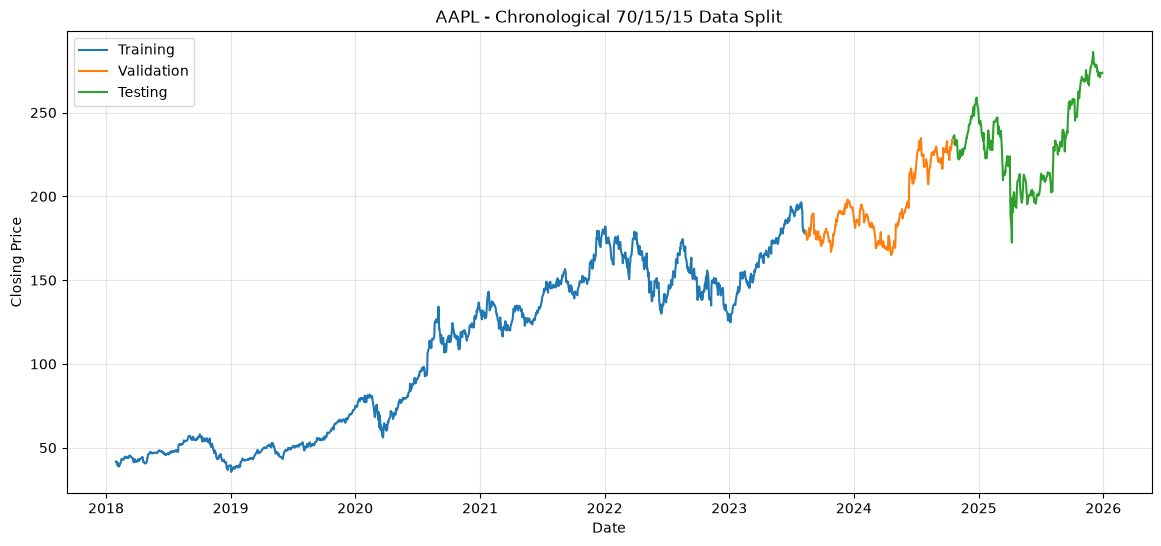

In [78]:
# Plot chronological 70/15/15 data split 
stock_name = "AAPL"

train = splits[stock_name]["train"]
validation = splits[stock_name]["validation"]
test = splits[stock_name]["test"]

plt.figure(figsize=(14, 6))

plt.plot(train["Date"], train["Close"], label="Training")
plt.plot(validation["Date"], validation["Close"], label="Validation")
plt.plot(test["Date"], test["Close"], label="Testing")

plt.title(f"{stock_name} - Chronological 70/15/15 Data Split")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [79]:
# Min-Max Scaling
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "SMA_10",
    "SMA_20",
    "EMA_10",
    "Volatility_10",
    "Close_Lag_1",
    "Return_Lag_1",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

target_column = "Target"

In [80]:
# Store scaled datasets and scalers
scaled_splits = {}
scalers = {}

for stock_name, data in splits.items():

    # Get chronological splits
    train = data["train"].copy()
    validation = data["validation"].copy()
    test = data["test"].copy()

    # Create separate scalers for X and y
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit ONLY on training data
    feature_scaler.fit(train[feature_columns])
    target_scaler.fit(train[[target_column]])

    # Transform training, validation and test
    # using training-fitted scalers
    X_train = feature_scaler.transform(
        train[feature_columns]
    )

    X_val = feature_scaler.transform(
        validation[feature_columns]
    )

    X_test = feature_scaler.transform(
        test[feature_columns]
    )

    y_train = target_scaler.transform(
        train[[target_column]]
    )

    y_val = target_scaler.transform(
        validation[[target_column]]
    )

    y_test = target_scaler.transform(
        test[[target_column]]
    )
    
    # Store results
    scaled_splits[stock_name] = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }

    # Save scalers for inverse transformation later
    scalers[stock_name] = {
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler
    }

    print(f"{stock_name} scaling completed.")

AAPL scaling completed.
NVDA scaling completed.
JPM scaling completed.
BHP scaling completed.
CBA scaling completed.
GMG scaling completed.


In [81]:
for stock_name, data in scaled_splits.items():

    print(f"\n{stock_name}")
    print("X_train:", data["X_train"].shape)
    print("X_val:  ", data["X_val"].shape)
    print("X_test: ", data["X_test"].shape)

    print("y_train:", data["y_train"].shape)
    print("y_val:  ", data["y_val"].shape)
    print("y_test: ", data["y_test"].shape)


AAPL
X_train: (1393, 15)
X_val:   (298, 15)
X_test:  (299, 15)
y_train: (1393, 1)
y_val:   (298, 1)
y_test:  (299, 1)

NVDA
X_train: (1393, 15)
X_val:   (298, 15)
X_test:  (299, 15)
y_train: (1393, 1)
y_val:   (298, 1)
y_test:  (299, 1)

JPM
X_train: (1393, 15)
X_val:   (298, 15)
X_test:  (299, 15)
y_train: (1393, 1)
y_val:   (298, 1)
y_test:  (299, 1)

BHP
X_train: (1402, 15)
X_val:   (301, 15)
X_test:  (301, 15)
y_train: (1402, 1)
y_val:   (301, 1)
y_test:  (301, 1)

CBA
X_train: (1402, 15)
X_val:   (301, 15)
X_test:  (301, 15)
y_train: (1402, 1)
y_val:   (301, 1)
y_test:  (301, 1)

GMG
X_train: (1402, 15)
X_val:   (301, 15)
X_test:  (301, 15)
y_train: (1402, 1)
y_val:   (301, 1)
y_test:  (301, 1)


In [82]:
# Check scaled data ranges
stock_name = "AAPL"

X_train = scaled_splits[stock_name]["X_train"]
X_val = scaled_splits[stock_name]["X_val"]
X_test = scaled_splits[stock_name]["X_test"]

print("Training minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))

print("Validation minimum:", np.min(X_val))
print("Validation maximum:", np.max(X_val))

print("Test minimum:", np.min(X_test))
print("Test maximum:", np.max(X_test))

Training minimum: 0.0
Training maximum: 1.0000000000000002
Validation minimum: -0.01875678075634639
Validation maximum: 1.2511076443057723
Test minimum: -0.27972309984279886
Test maximum: 1.5613728549141965


In [83]:
# Create 60-Day Sequences
LOOKBACK = 60

def create_sequences_with_context(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    lookback=60
):
    """
    Create sequences while preserving historical context
    across train/validation/test boundaries.
    """
    
    # Training sequences
    X_train_seq = []
    y_train_seq = []

    for i in range(lookback, len(X_train)):
        X_train_seq.append(
            X_train[i-lookback:i]
        )
        y_train_seq.append(
            y_train[i]
        )

    # Validation sequences
    # Include final 'lookback' training rows as historical context.
    X_val_context = np.concatenate(
        [X_train[-lookback:], X_val],
        axis=0
    )

    y_val_context = np.concatenate(
        [y_train[-lookback:], y_val],
        axis=0
    )

    X_val_seq = []
    y_val_seq = []

    for i in range(lookback, len(X_val_context)):
        X_val_seq.append(
            X_val_context[i-lookback:i]
        )
        y_val_seq.append(
            y_val_context[i]
        )

    # Test sequences
    # Include final validation rows as historical context.
    X_test_context = np.concatenate(
        [X_val[-lookback:], X_test],
        axis=0
    )

    y_test_context = np.concatenate(
        [y_val[-lookback:], y_test],
        axis=0
    )

    X_test_seq = []
    y_test_seq = []

    for i in range(lookback, len(X_test_context)):
        X_test_seq.append(
            X_test_context[i-lookback:i]
        )
        y_test_seq.append(
            y_test_context[i]
        )

    return (
        np.array(X_train_seq),
        np.array(y_train_seq),
        np.array(X_val_seq),
        np.array(y_val_seq),
        np.array(X_test_seq),
        np.array(y_test_seq)
    )

In [84]:
# Create sequences for all stocks
sequence_data = {}

for stock_name, data in scaled_splits.items():

    (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
        X_test_seq,
        y_test_seq
    ) = create_sequences_with_context(
        data["X_train"],
        data["y_train"],
        data["X_val"],
        data["y_val"],
        data["X_test"],
        data["y_test"],
        lookback=LOOKBACK
    )

    sequence_data[stock_name] = {
        "X_train": X_train_seq,
        "y_train": y_train_seq,
        "X_val": X_val_seq,
        "y_val": y_val_seq,
        "X_test": X_test_seq,
        "y_test": y_test_seq
    }

    print(f"\n{stock_name}")
    print("X_train:", X_train_seq.shape)
    print("y_train:", y_train_seq.shape)
    print("X_val:  ", X_val_seq.shape)
    print("y_val:  ", y_val_seq.shape)
    print("X_test: ", X_test_seq.shape)
    print("y_test: ", y_test_seq.shape)


AAPL
X_train: (1333, 60, 15)
y_train: (1333, 1)
X_val:   (298, 60, 15)
y_val:   (298, 1)
X_test:  (299, 60, 15)
y_test:  (299, 1)

NVDA
X_train: (1333, 60, 15)
y_train: (1333, 1)
X_val:   (298, 60, 15)
y_val:   (298, 1)
X_test:  (299, 60, 15)
y_test:  (299, 1)

JPM
X_train: (1333, 60, 15)
y_train: (1333, 1)
X_val:   (298, 60, 15)
y_val:   (298, 1)
X_test:  (299, 60, 15)
y_test:  (299, 1)

BHP
X_train: (1342, 60, 15)
y_train: (1342, 1)
X_val:   (301, 60, 15)
y_val:   (301, 1)
X_test:  (301, 60, 15)
y_test:  (301, 1)

CBA
X_train: (1342, 60, 15)
y_train: (1342, 1)
X_val:   (301, 60, 15)
y_val:   (301, 1)
X_test:  (301, 60, 15)
y_test:  (301, 1)

GMG
X_train: (1342, 60, 15)
y_train: (1342, 1)
X_val:   (301, 60, 15)
y_val:   (301, 1)
X_test:  (301, 60, 15)
y_test:  (301, 1)


In [85]:
# LSTM Model

# Reproducibility
tf.keras.utils.set_random_seed(42)

# Build LSTM Model
def build_lstm_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        LSTM(
            64,
            return_sequences=True
        ),

        Dropout(0.2),

        LSTM(
            32,
            return_sequences=False
        ),

        Dropout(0.2),

        Dense(
            16,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [86]:
# Train LSTM Models for All Six Stocks
lstm_models = {}
lstm_histories = {}
lstm_predictions = {}

for stock_name, data in sequence_data.items():

    print("\n" + "=" * 60)
    print(f"Training LSTM for {stock_name}")
    print("=" * 60)

    # Get sequence data
    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    print("Train shape:", X_train.shape, y_train.shape)
    print("Validation shape:", X_val.shape, y_val.shape)
    print("Test shape:", X_test.shape, y_test.shape)

    # Build a fresh model for this stock
    model = build_lstm_model(
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=100,
        batch_size=32,

        callbacks=[
            early_stopping
        ],

        shuffle=False,
        verbose=0
    )

    # Generate predictions
    y_pred_scaled = model.predict(
        X_test,
        verbose=0
    )

    # Convert predictions back to original price scale
    target_scaler = scalers[
        stock_name
    ]["target_scaler"]

    y_pred = target_scaler.inverse_transform(
        y_pred_scaled
    )

    y_actual = target_scaler.inverse_transform(
        y_test
    )

    # Store model
    lstm_models[stock_name] = model

    # Store training history
    lstm_histories[stock_name] = history

    # Store predictions
    lstm_predictions[stock_name] = {
        "actual": y_actual.flatten(),
        "predicted": y_pred.flatten()
    }

    # Show training information
    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    best_val_loss = min(
        history.history["val_loss"]
    )

    print(
        f"{stock_name} completed."
    )

    print(
        f"Epochs trained: "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )


Training LSTM for AAPL
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
AAPL completed.
Epochs trained: 25
Best epoch: 15
Best validation loss: 0.004488

Training LSTM for NVDA
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
NVDA completed.
Epochs trained: 49
Best epoch: 39
Best validation loss: 0.291961

Training LSTM for JPM
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
JPM completed.
Epochs trained: 24
Best epoch: 14
Best validation loss: 0.073131

Training LSTM for BHP
Train shape: (1342, 60, 15) (1342, 1)
Validation shape: (301, 60, 15) (301, 1)
Test shape: (301, 60, 15) (301, 1)
BHP completed.
Epochs trained: 55
Best epoch: 45
Best validation loss: 0.001220

Training LSTM for CBA
Train shape: (1342, 60, 15) (1342, 1)
Validation shape: (301, 60, 15) (301, 1)
Test shape: (301, 60, 15) 

In [87]:
# Plot LSTM Training History
def plot_lstm_history(stock_name):

    history = lstm_histories[
        stock_name
    ]

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.axvline(
        x=best_epoch - 1,
        linestyle="--",
        label=f"Best Epoch = {best_epoch}"
    )

    plt.title(
        f"{stock_name} LSTM - "
        f"Training and Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

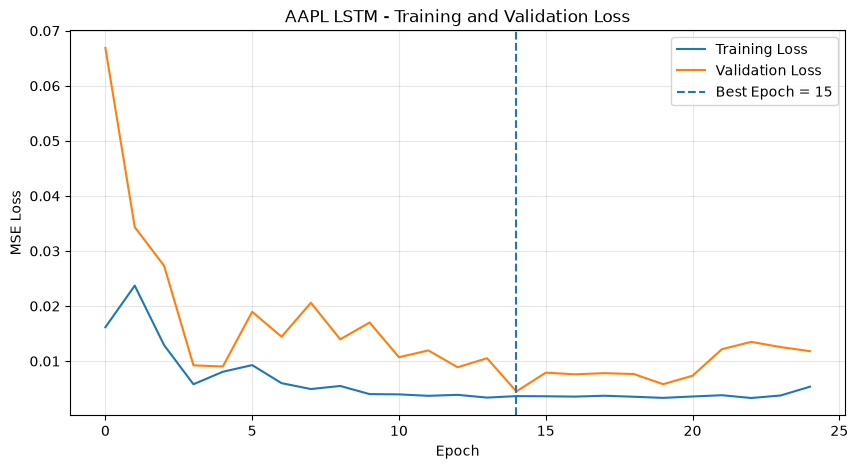

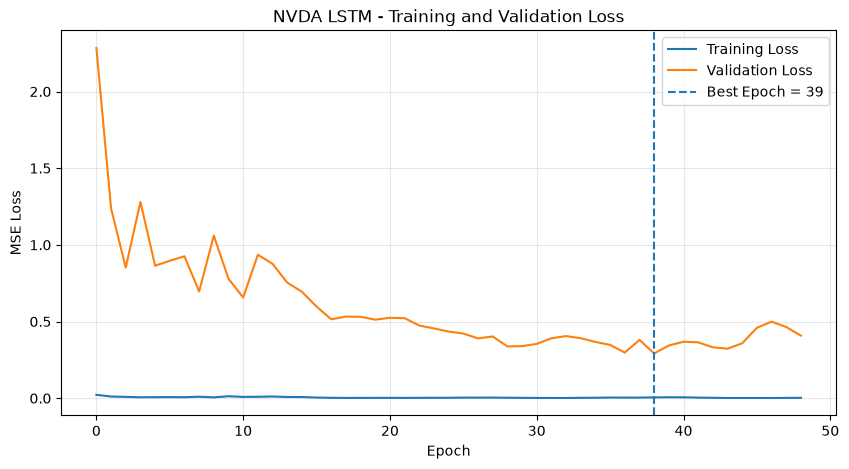

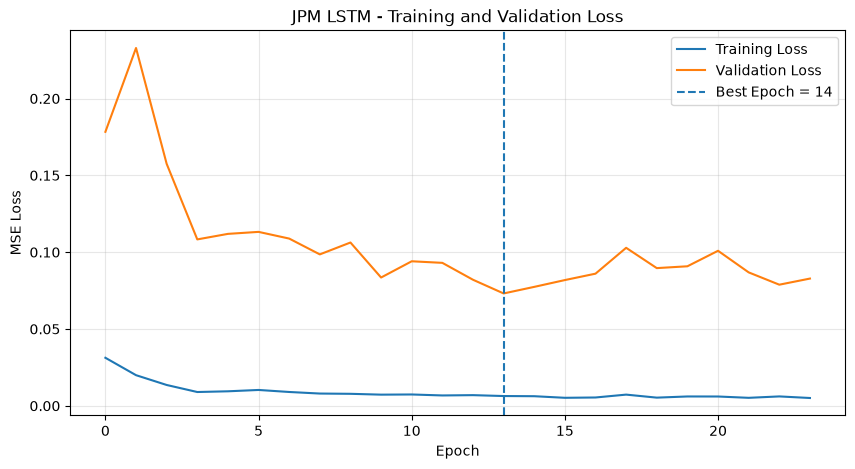

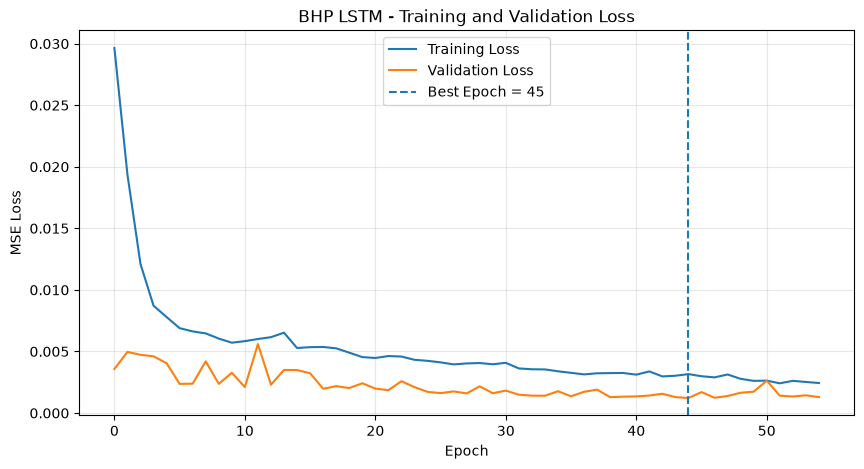

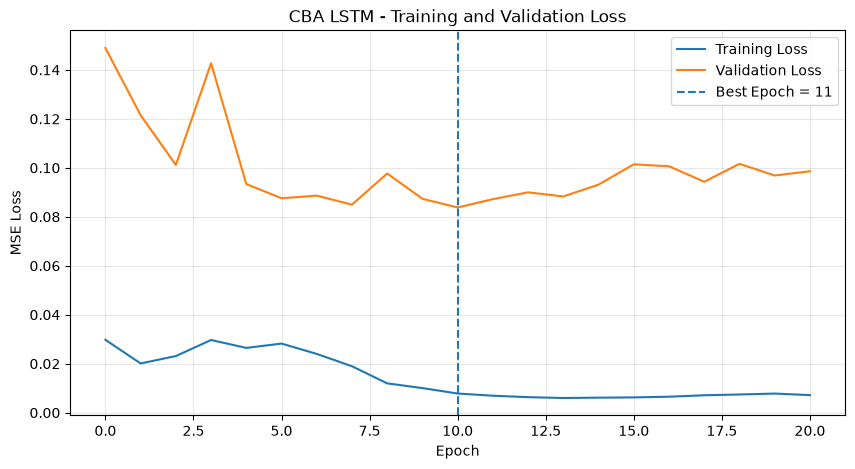

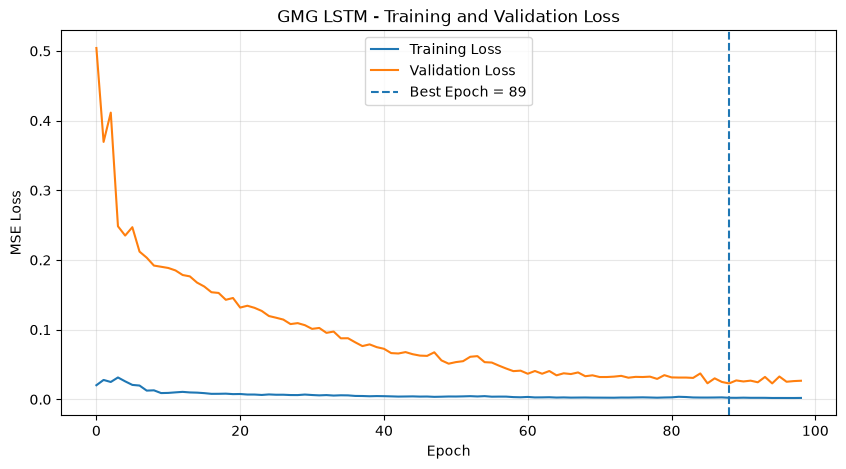

In [88]:
for stock_name in sequence_data.keys():
    plot_lstm_history(stock_name)

In [89]:
# Plot LSTM Actual vs Predicted
def plot_lstm_predictions(stock_name):

    actual = lstm_predictions[
        stock_name
    ]["actual"]

    predicted = lstm_predictions[
        stock_name
    ]["predicted"]

    plt.figure(figsize=(14, 6))
    plt.plot(
        actual,
        label="Actual Close"
    )
    plt.plot(
        predicted,
        label="LSTM Predicted Close"
    )
    plt.title(
        f"{stock_name} LSTM - "
        f"Actual vs Predicted Closing Price"
    )
    plt.xlabel("Test Observation")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

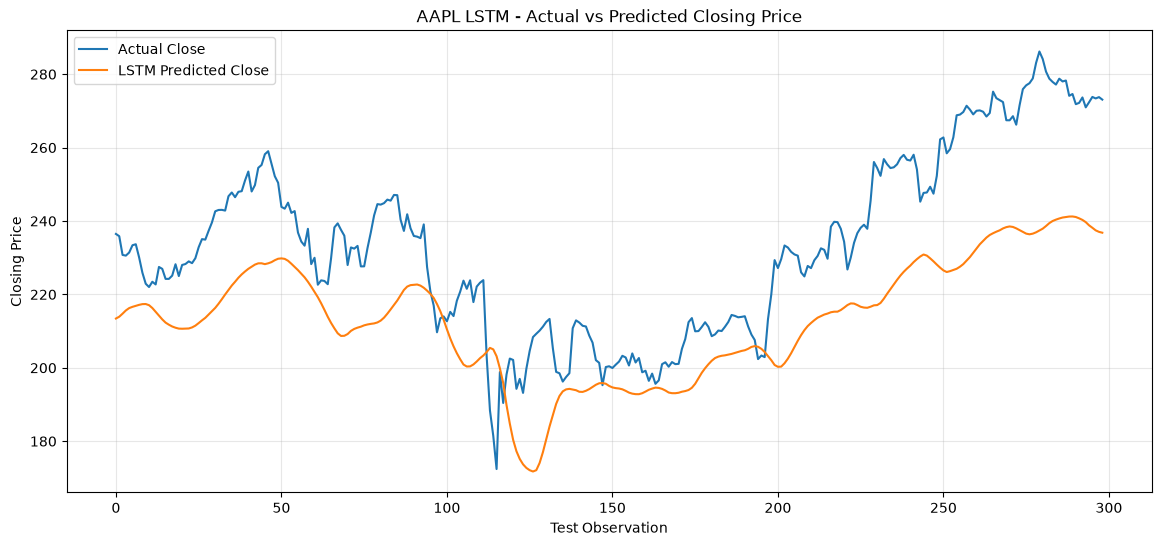

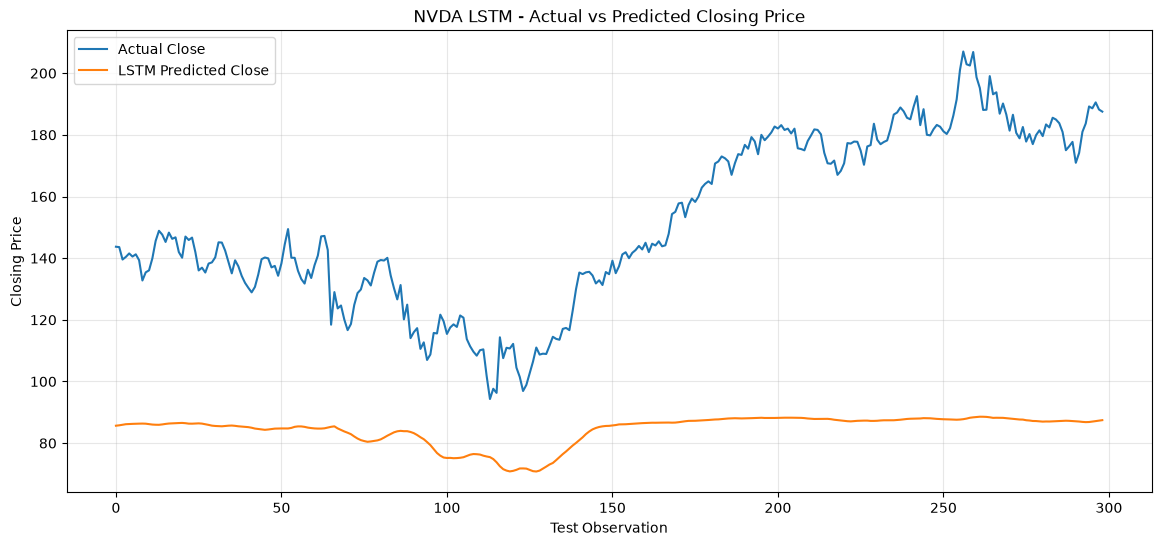

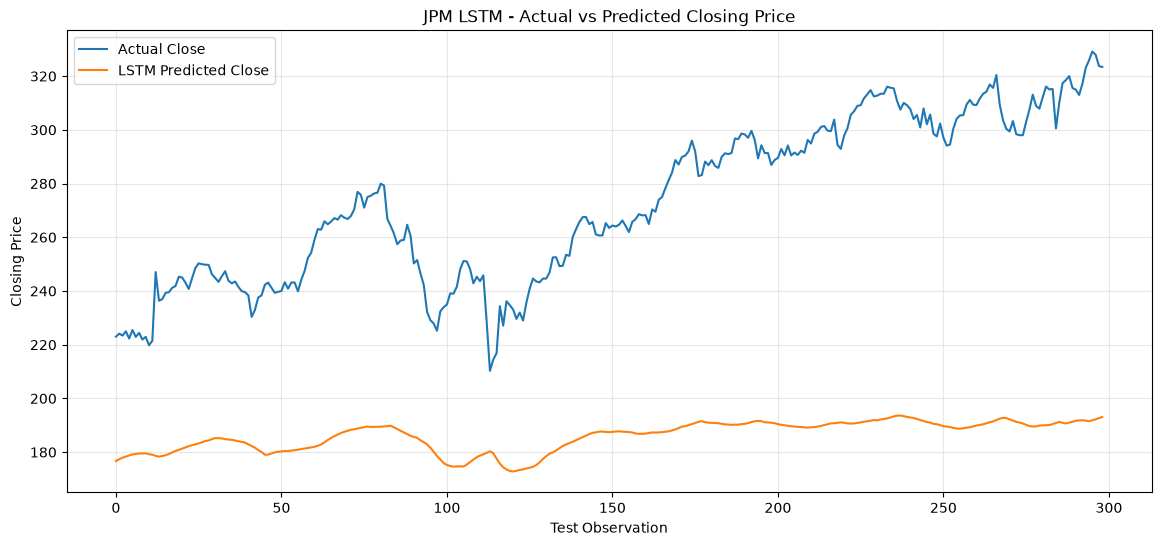

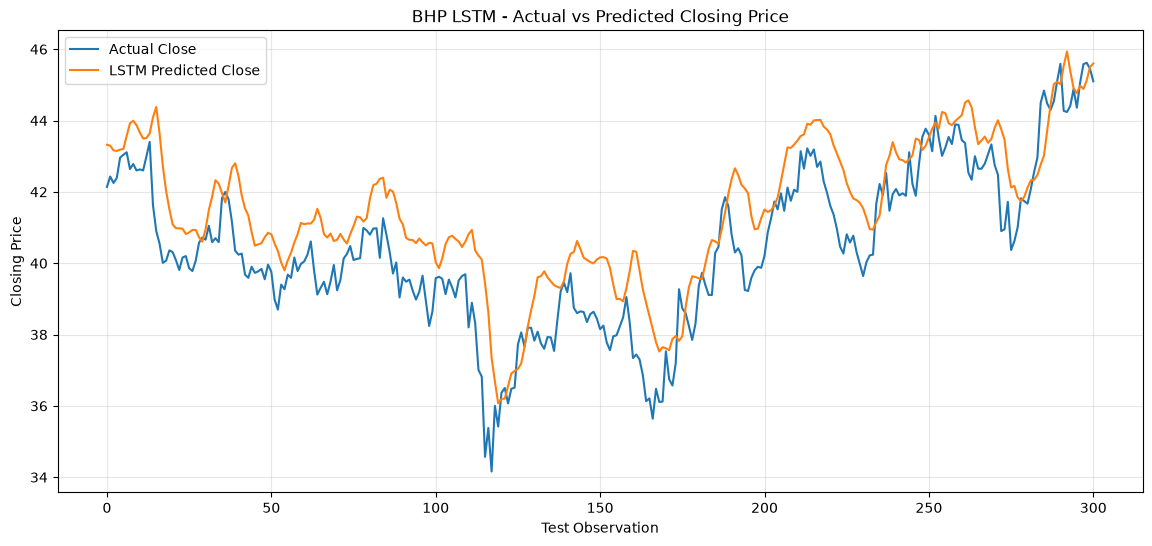

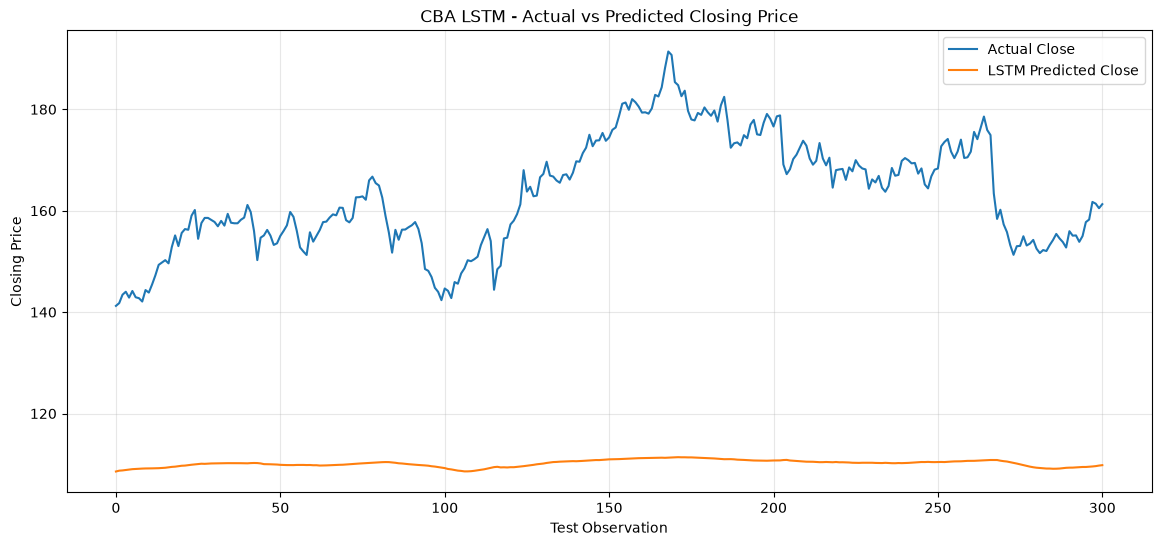

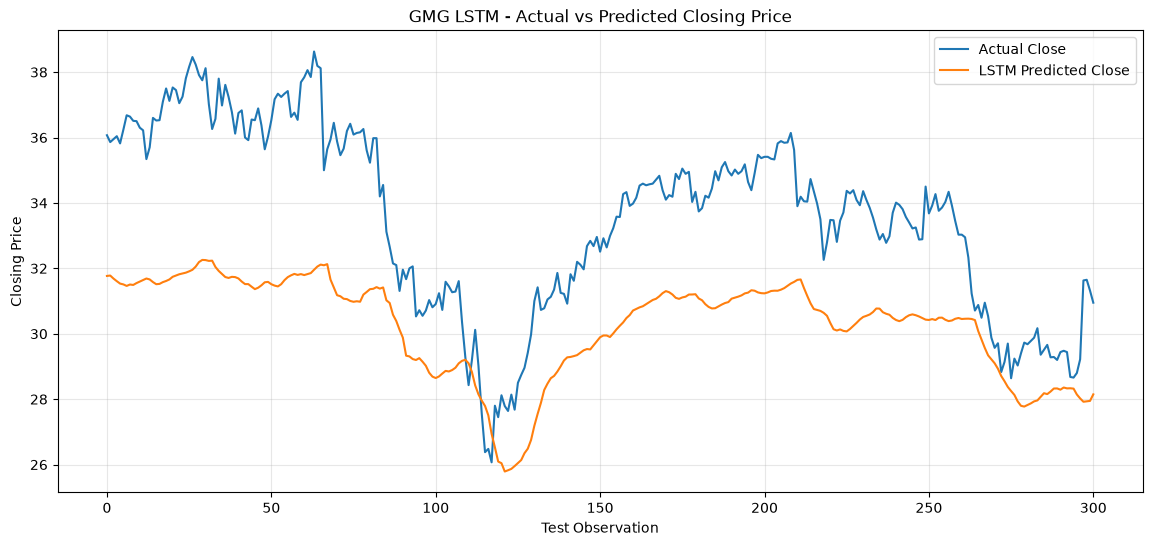

In [90]:
for stock_name in sequence_data.keys():
    plot_lstm_predictions(stock_name)

In [91]:
# First 10 LSTM Predictions
for stock_name in sequence_data.keys():
    print("\n" + "=" * 30)
    print(stock_name)
    print("=" * 30)
    
    comparison = pd.DataFrame({
        "Actual":
            lstm_predictions[
                stock_name
            ]["actual"],

        "Predicted":
            lstm_predictions[
                stock_name
            ]["predicted"]
    })
    print(comparison.head(10))


AAPL
   Actual   Predicted
0  236.48  213.428329
1  235.86  213.924576
2  230.76  214.747711
3  230.57  215.629120
4  231.41  216.272293
5  233.40  216.614258
6  233.67  216.890976
7  230.10  217.154617
8  225.91  217.353836
9  222.91  217.380127

NVDA
   Actual  Predicted
0  143.71  85.654037
1  143.59  85.780388
2  139.56  85.962265
3  140.41  86.142441
4  141.54  86.210663
5  140.52  86.249870
6  141.25  86.296188
7  139.34  86.320778
8  132.76  86.343239
9  135.40  86.307625

JPM
   Actual   Predicted
0  223.00  176.680069
1  224.12  177.348694
2  223.41  177.959793
3  224.98  178.333923
4  222.31  178.790543
5  225.50  179.132904
6  222.90  179.297958
7  224.41  179.493851
8  221.92  179.519409
9  222.94  179.547012

BHP
   Actual  Predicted
0   42.14  43.320213
1   42.43  43.293278
2   42.25  43.162975
3   42.39  43.146511
4   42.96  43.185799
5   43.04  43.200417
6   43.11  43.570900
7   42.64  43.920532
8   42.78  43.993774
9   42.60  43.868511

CBA
   Actual   Predicted
0  14

In [92]:
# CNN-LSTM Model
def build_cnn_lstm_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        # CNN extracts local temporal patterns
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        MaxPooling1D(
            pool_size=2
        ),

        # LSTM learns longer-term temporal dependencies
        LSTM(
            64,
            return_sequences=False
        ),

        Dropout(0.2),

        Dense(
            16,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [93]:
# Train CNN-LSTM Models for All Six Stocks
cnn_lstm_models = {}
cnn_lstm_histories = {}
cnn_lstm_predictions = {}

for stock_name, data in sequence_data.items():

    print("\n" + "=" * 60)
    print(f"Training CNN-LSTM for {stock_name}")
    print("=" * 60)

    # Sequence data
    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    print("Train shape:", X_train.shape, y_train.shape)
    print("Validation shape:", X_val.shape, y_val.shape)
    print("Test shape:", X_test.shape, y_test.shape)

    # Fresh CNN-LSTM model for each stock
    model = build_cnn_lstm_model(
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # Train
    history = model.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=100,
        batch_size=32,

        callbacks=[
            early_stopping
        ],

        shuffle=False,
        verbose=0
    )

    # Generate test predictions
    y_pred_scaled = model.predict(
        X_test,
        verbose=0
    )

    # Target scaler belonging to this stock
    target_scaler = scalers[
        stock_name
    ]["target_scaler"]

    # Convert back to actual stock-price scale
    y_pred = target_scaler.inverse_transform(
        y_pred_scaled
    )

    y_actual = target_scaler.inverse_transform(
        y_test
    )

    # Save everything separately from LSTM
    cnn_lstm_models[stock_name] = model

    cnn_lstm_histories[stock_name] = history

    cnn_lstm_predictions[stock_name] = {
        "actual": y_actual.flatten(),
        "predicted": y_pred.flatten()
    }

    # Best validation epoch
    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    best_val_loss = min(
        history.history["val_loss"]
    )

    print(f"{stock_name} completed.")
    print(
        f"Epochs trained: "
        f"{len(history.history['loss'])}"
    )
    print(
        f"Best epoch: {best_epoch}"
    )
    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )


Training CNN-LSTM for AAPL
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
AAPL completed.
Epochs trained: 14
Best epoch: 4
Best validation loss: 0.002207

Training CNN-LSTM for NVDA
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
NVDA completed.
Epochs trained: 68
Best epoch: 58
Best validation loss: 0.060533

Training CNN-LSTM for JPM
Train shape: (1333, 60, 15) (1333, 1)
Validation shape: (298, 60, 15) (298, 1)
Test shape: (299, 60, 15) (299, 1)
JPM completed.
Epochs trained: 18
Best epoch: 8
Best validation loss: 0.057550

Training CNN-LSTM for BHP
Train shape: (1342, 60, 15) (1342, 1)
Validation shape: (301, 60, 15) (301, 1)
Test shape: (301, 60, 15) (301, 1)
BHP completed.
Epochs trained: 37
Best epoch: 27
Best validation loss: 0.001150

Training CNN-LSTM for CBA
Train shape: (1342, 60, 15) (1342, 1)
Validation shape: (301, 60, 15) (301, 1)
Test sha

In [94]:
# Plot CNN-LSTM Training History
def plot_cnn_lstm_history(stock_name):

    history = cnn_lstm_histories[
        stock_name
    ]

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    plt.figure(figsize=(10, 5))
    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )
    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )
    plt.axvline(
        x=best_epoch - 1,
        linestyle="--",
        label=f"Best Epoch = {best_epoch}"
    )
    plt.title(
        f"{stock_name} CNN-LSTM - "
        f"Training and Validation Loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

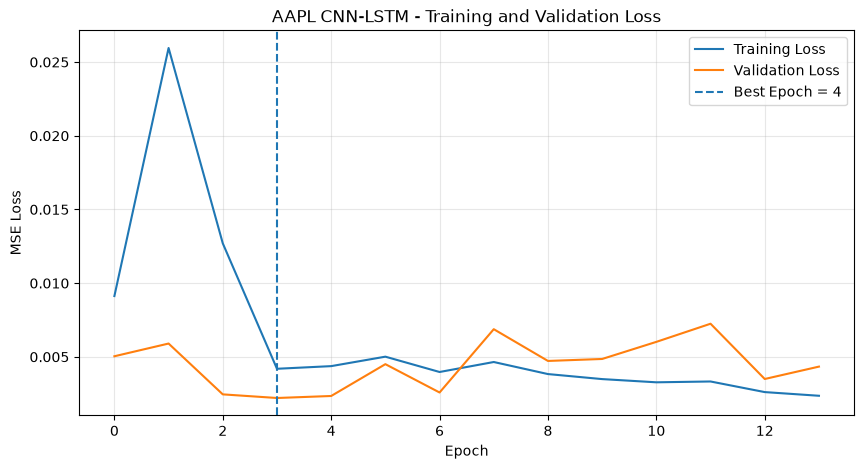

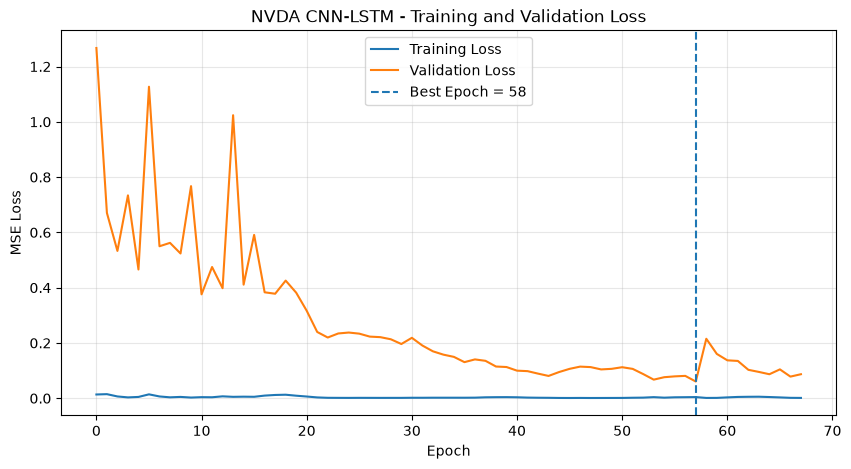

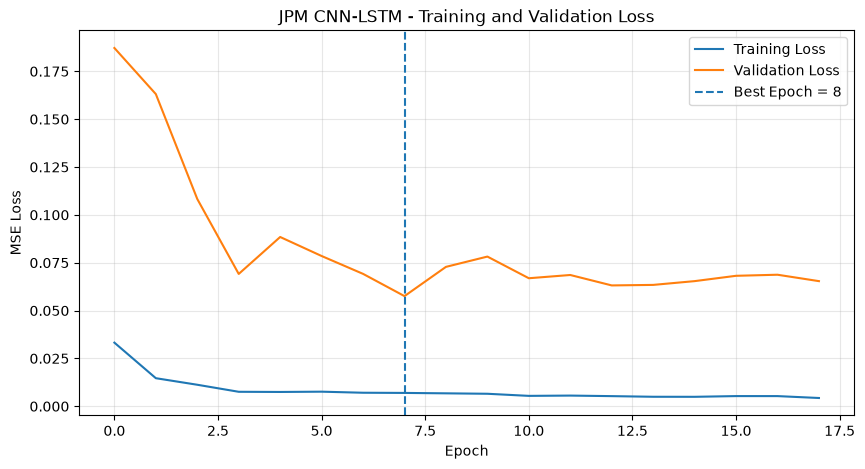

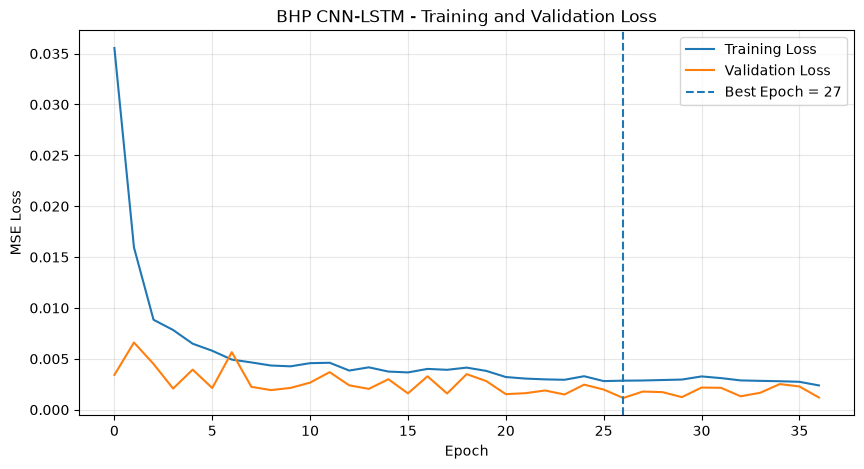

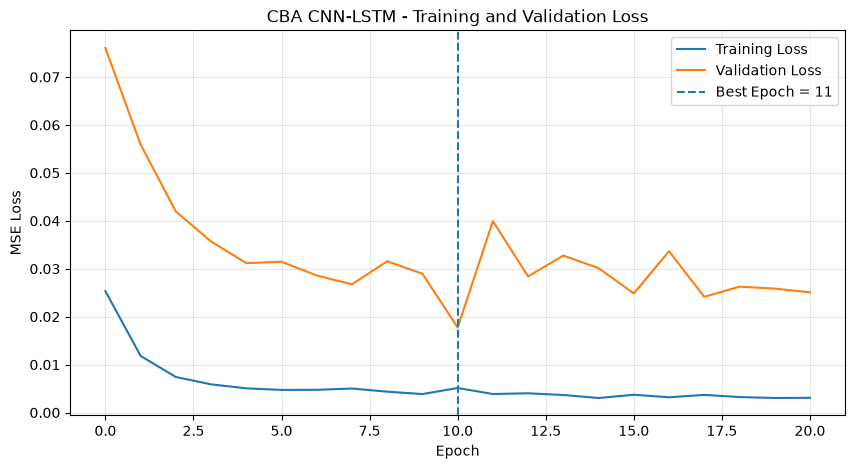

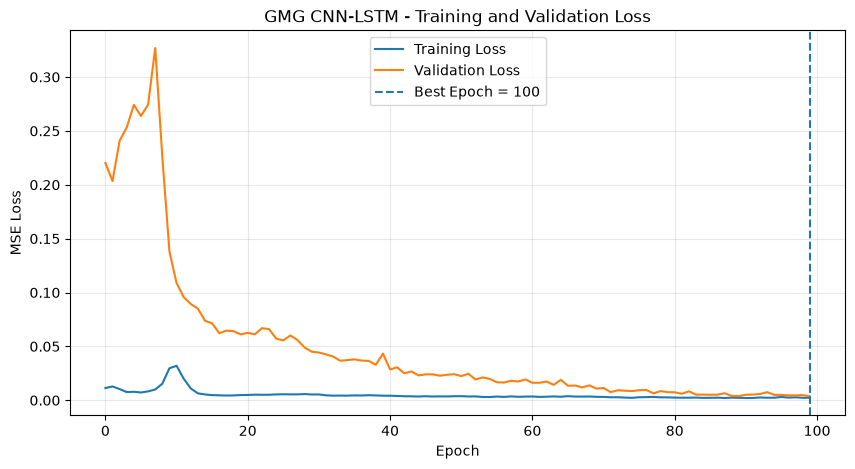

In [95]:
for stock_name in sequence_data.keys():
    plot_cnn_lstm_history(stock_name)

In [96]:
# CNN-LSTM Actual vs Predicted
def plot_cnn_lstm_predictions(stock_name):

    actual = cnn_lstm_predictions[
        stock_name
    ]["actual"]

    predicted = cnn_lstm_predictions[
        stock_name
    ]["predicted"]

    plt.figure(figsize=(14, 6))
    plt.plot(
        actual,
        label="Actual Close"
    )
    plt.plot(
        predicted,
        label="CNN-LSTM Predicted Close"
    )
    plt.title(
        f"{stock_name} CNN-LSTM - "
        f"Actual vs Predicted Closing Price"
    )
    plt.xlabel("Test Observation")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

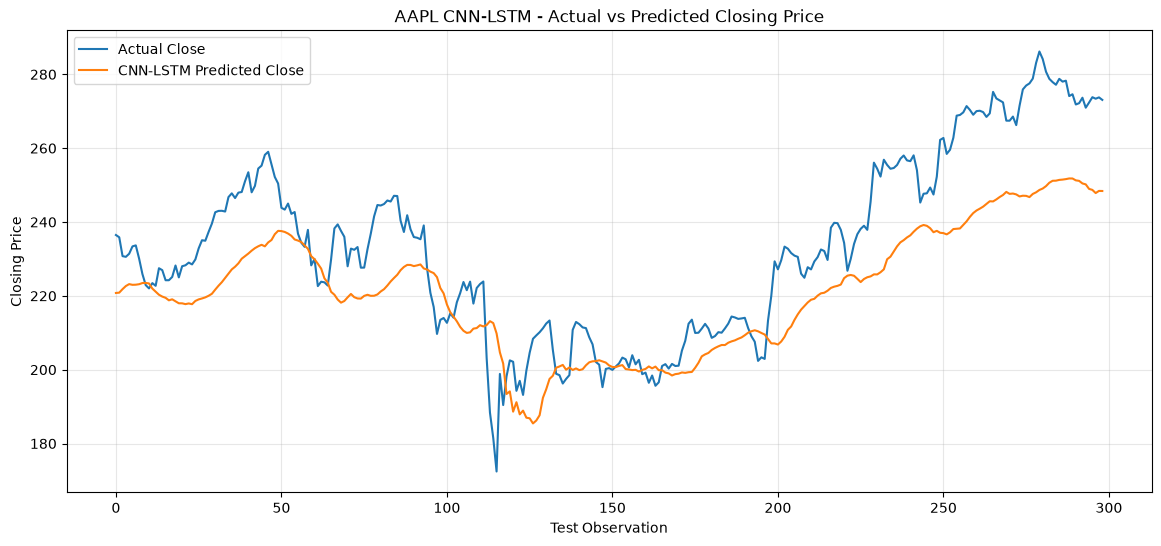

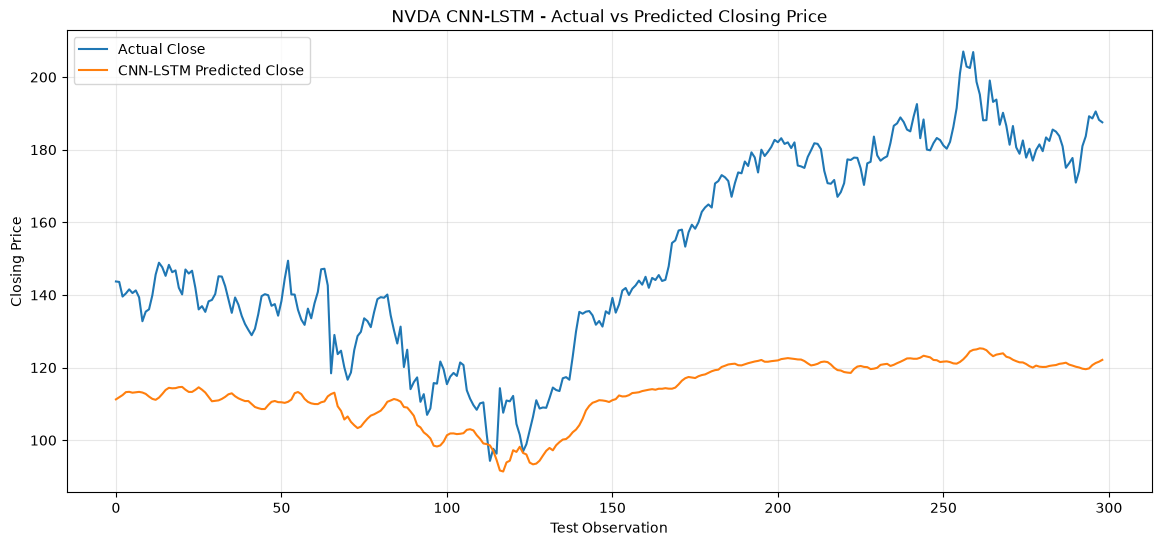

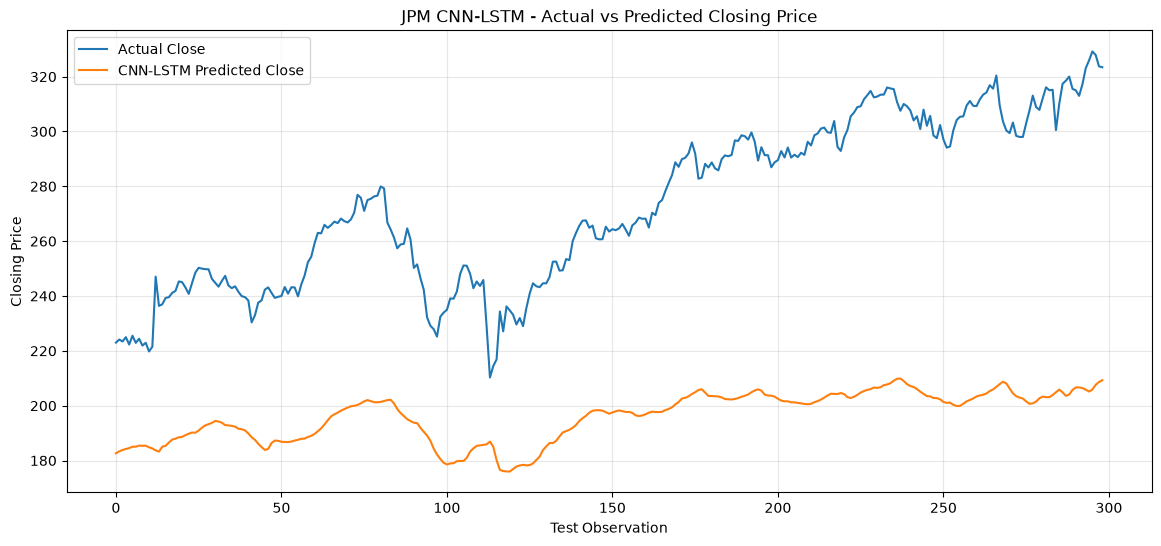

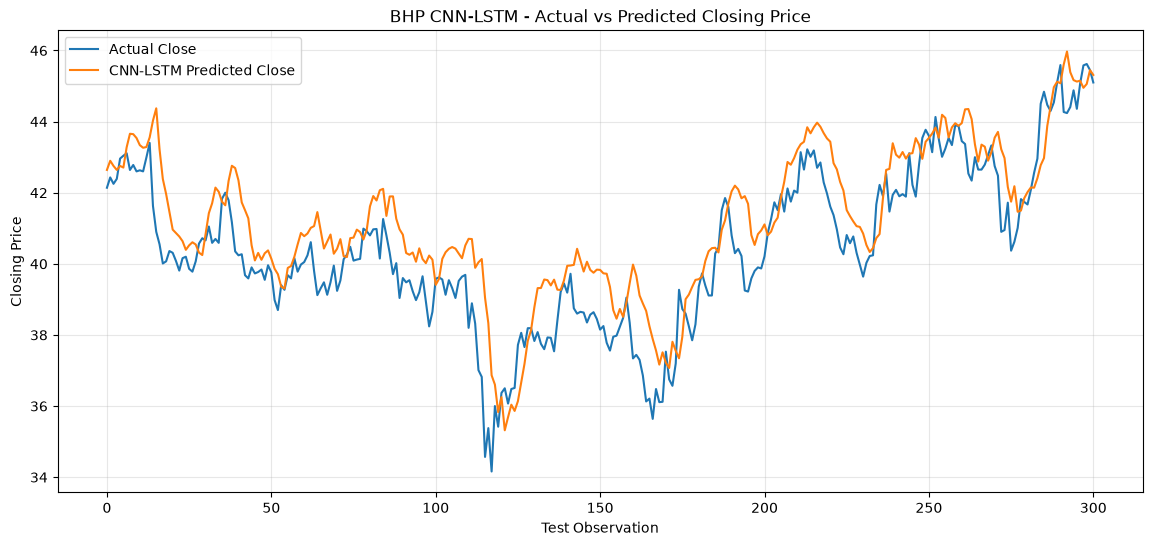

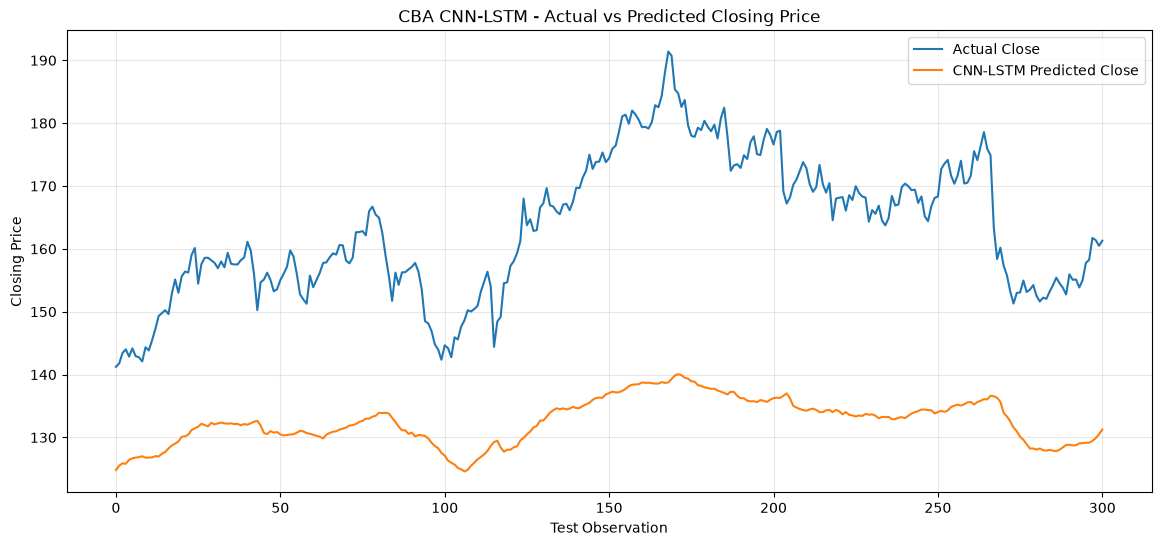

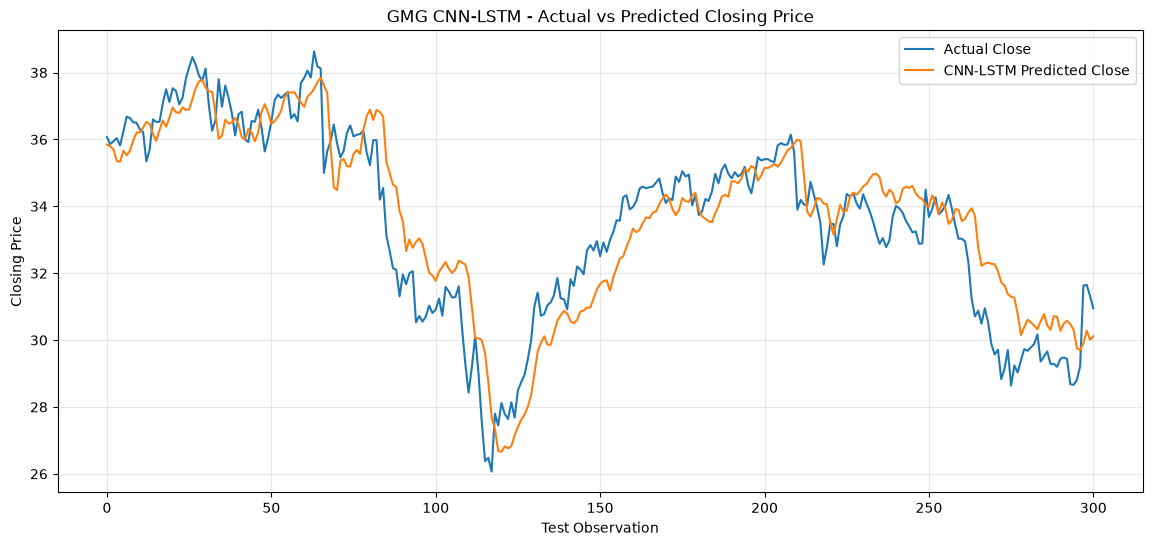

In [97]:
for stock_name in sequence_data.keys():
    plot_cnn_lstm_predictions(stock_name)

In [98]:
# First 10 CNN-LSTM Predictions
for stock_name in sequence_data.keys():
    print("\n" + "=" * 30)
    print(stock_name)
    print("=" * 30)

    comparison = pd.DataFrame({
        "Actual":
            cnn_lstm_predictions[
                stock_name
            ]["actual"],

        "Predicted":
            cnn_lstm_predictions[
                stock_name
            ]["predicted"]
    })
    print(comparison.head(10))


AAPL
   Actual   Predicted
0  236.48  220.780838
1  235.86  220.867172
2  230.76  221.820053
3  230.57  222.661896
4  231.41  223.177887
5  233.40  222.986252
6  233.67  223.020752
7  230.10  223.150711
8  225.91  223.468094
9  222.91  223.505371

NVDA
   Actual   Predicted
0  143.71  111.246857
1  143.59  111.838142
2  139.56  112.423080
3  140.41  113.240059
4  141.54  113.324722
5  140.52  113.084351
6  141.25  113.210007
7  139.34  113.310249
8  132.76  113.134529
9  135.40  112.755409

JPM
   Actual   Predicted
0  223.00  182.615219
1  224.12  183.340744
2  223.41  183.840805
3  224.98  184.215576
4  222.31  184.506607
5  225.50  185.030518
6  222.90  185.031647
7  224.41  185.426682
8  221.92  185.358566
9  222.94  185.392410

BHP
   Actual  Predicted
0   42.14  42.641037
1   42.43  42.898205
2   42.25  42.753315
3   42.39  42.641029
4   42.96  42.753654
5   43.04  42.707371
6   43.11  43.278381
7   42.64  43.657852
8   42.78  43.646904
9   42.60  43.538467

CBA
   Actual   Pred